In [1]:
import rasterio
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib

vv_src = rasterio.open('Sentinel1_VV.tif')
ndvi_src = rasterio.open('NDVI.tif')
ndwi_src = rasterio.open('NDWI.tif')

vv = vv_src.read(1)
ndvi = ndvi_src.read(1)
ndwi = ndwi_src.read(1)

height, width = vv.shape

vv_flat = vv.flatten()
ndvi_flat = ndvi.flatten()
ndwi_flat = ndwi.flatten()

mask = (
    (~np.isnan(vv_flat)) &
    (~np.isnan(ndvi_flat)) &
    (~np.isnan(ndwi_flat)) &
    (vv_flat != 0)
)

df = pd.DataFrame({
    'VV': vv_flat[mask],
    'NDVI': ndvi_flat[mask],
    'NDWI': ndwi_flat[mask]
})

df['Flood'] = (df['NDWI'] > 0.3).astype(int)

In [2]:
X = df[['VV', 'NDVI', 'NDWI']]
y = df['Flood']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [3]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

joblib.dump(model, 'trained_model.pkl')

probs = model.predict_proba(X)
df['Flood_Prob'] = probs[:, 1]


def recommend(p):
    if p > 0.7:
        return 2   # High Risk
    elif p > 0.4:
        return 1   # Medium
    else:
        return 0   # Low Risk

df['Decision'] = df['Flood_Prob'].apply(recommend)

full_prob = np.full(vv_flat.shape, np.nan)
full_prob[mask] = df['Flood_Prob'].values

risk_map = full_prob.reshape(height, width)

# Decision map
full_decision = np.full(vv_flat.shape, -1)
full_decision[mask] = df['Decision'].values

decision_map = full_decision.reshape(height, width)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   5406096
           1       1.00      1.00      1.00    906606

    accuracy                           1.00   6312702
   macro avg       1.00      1.00      1.00   6312702
weighted avg       1.00      1.00      1.00   6312702



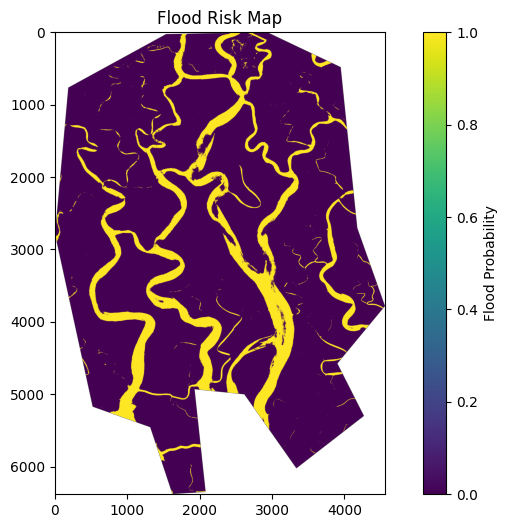

✅ Maps saved successfully!


In [4]:

plt.figure(figsize=(10, 6))
plt.imshow(risk_map)
plt.colorbar(label="Flood Probability")
plt.title("Flood Risk Map")
plt.show()


with rasterio.open(
    'flood_risk_map.tif',
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=risk_map.dtype,
    crs=vv_src.crs,
    transform=vv_src.transform
) as dst:
    dst.write(risk_map, 1)

# Save decision map too
with rasterio.open(
    'decision_map.tif',
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=risk_map.dtype,
    crs=vv_src.crs,
    transform=vv_src.transform
) as dst:
    dst.write(decision_map, 1)

print("✅ Maps saved successfully!")
